In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


 SECTION A:

 1) what is the difference between a .py file and a .ipynb file ?

 A .py file contains only Python code, while an .ipynb file includes code, output, graphs, and explanations together.

Example:
program.py → only coding
analysis.ipynb → code + charts + results

2) what is the difference between a numerical feature and a categorical feature ?

Numerical features contain measurable values, while categorical features contain labels or categories.

Example from dataset:
Numerical → age = 52, chol = 271
Categorical → sex = Male, cp = Chest Pain Type

3) why does the data type of your target variable matter before framing a prediction problem ?

The datatype of the target variable helps decide the machine learning problem type.

Example:
target = 0 or 1 → Classification problem
House price prediction → Regression problem

4) what does a correlation value tell you about two variables ?

Correlation shows the relationship between two variables.

Example:
0.23 → weak positive relation
As age increases, heart disease risk slightly increases

5) what is the fundamental difference between a rule-based system and a data-driven approach ?

A rule-based system uses fixed conditions, while a data-driven approach learns patterns from data.

Example:
Rule-based → if chol > 240
Data-driven → ML model predicts risk using multiple features like age, cholesterol, and heart rate together.

In [ ]:
#  SECTION B:( Practical Task)

""" 1) implement an automated data ingstion pipeline using pandas
       to load the UCI Heart Disease dataset and perform type
       casting for categorical variables like sex, cp and resteg ?
 """

# load dataset

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('heart_cleveland_upload.csv')
print(df)


Saving heart_cleveland_upload.csv to heart_cleveland_upload (1).csv
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     69    1   0       160   234    1        2      131      0      0.1   
1     69    0   0       140   239    0        0      151      0      1.8   
2     66    0   0       150   226    0        0      114      0      2.6   
3     65    1   0       138   282    1        2      174      0      1.4   
4     64    1   0       110   211    0        2      144      1      1.8   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
292   40    1   3       152   223    0        0      181      0      0.0   
293   39    1   3       118   219    0        0      140      0      1.2   
294   35    1   3       120   198    0        0      130      1      1.6   
295   35    0   3       138   183    0        0      182      0      1.4   
296   35    1   3       126   282    0        2      156      1      0.0   

     slope  ca  tha

In [ ]:
#  Display first 5 rows
print(df.head())

# Dataset information
print(df.info())

# Type casting categorical columns
categorical_cols = ['sex', 'cp', 'restecg']

for col in categorical_cols:
    df[col] = df[col].astype('category')

# Verify datatypes
print(df.dtypes)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       29


Outliers in chol:
     chol
79    564
83    417
180   407
188   394
238   409


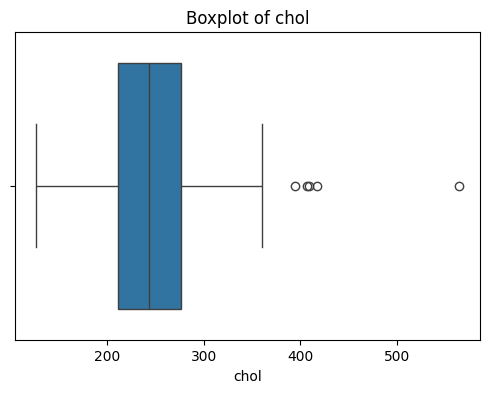


Outliers in thalach:
     thalach
164       71


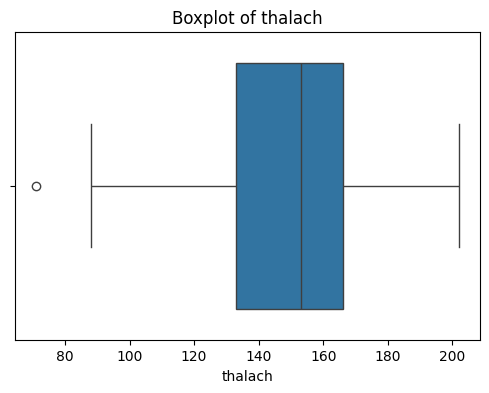

In [6]:
""" 2) execute a comprehensive outlier detection strategy on
       'chol'(cholestrol) and 'thalach'( max heart rate)
        using the IQR method and visualize the results via
        boxplots?  """


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Columns for outlier detection
columns = ['chol', 'thalach']

for col in columns:

    # Calculate Quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Lower and Upper limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Find outliers
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]])

    # Boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')
    plt.show()

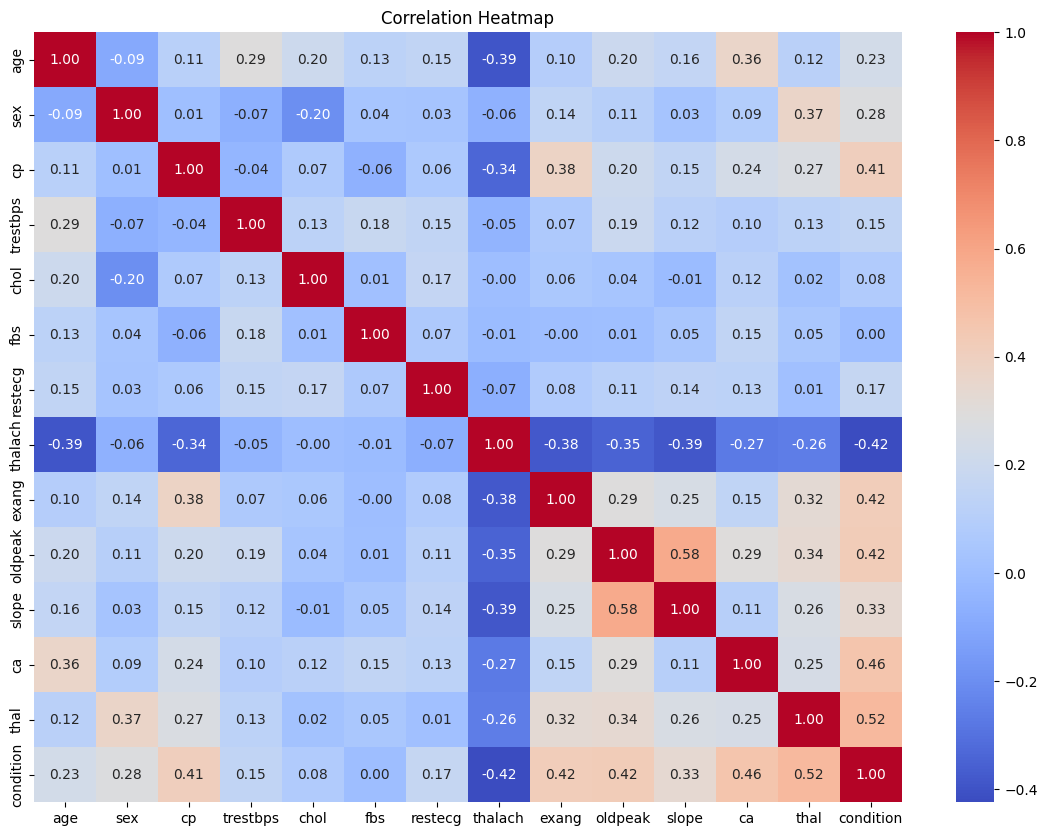


Correlation with Target:
condition    1.000000
thal         0.520516
ca           0.463189
oldpeak      0.424052
exang        0.421355
cp           0.408945
slope        0.333049
sex          0.278467
age          0.227075
restecg      0.166343
trestbps     0.153490
chol         0.080285
fbs          0.003167
thalach     -0.423817
Name: condition, dtype: float64


In [8]:
""" 3) How can Seaborn Heatmaps be used to identify correlations
  and multi-collinearity between clinical features and determine
  the variables most related to the target column?"""

# Correlation matrix
corr_matrix = df.corr()

# Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
target_corr = corr_matrix['condition'].sort_values(ascending=False)

print("\nCorrelation with Target:")
print(target_corr)

   age sex cp  trestbps  chol  fbs restecg  thalach  exang  oldpeak  slope  \
0   69   1  0       160   234    1       2      131      0      0.1      1   
1   69   0  0       140   239    0       0      151      0      1.8      0   
2   66   0  0       150   226    0       0      114      0      2.6      2   
3   65   1  0       138   282    1       2      174      0      1.4      1   
4   64   1  0       110   211    0       2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64
(297, 14)


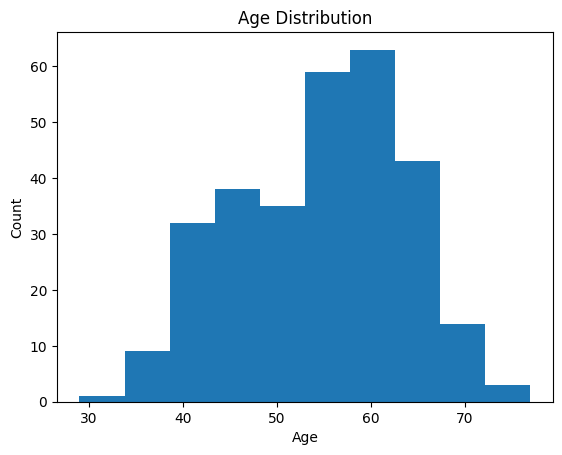

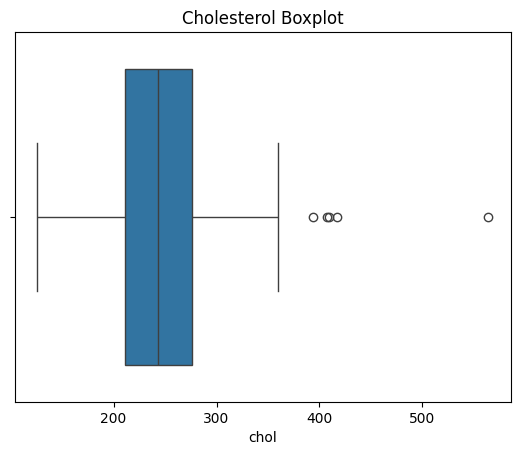

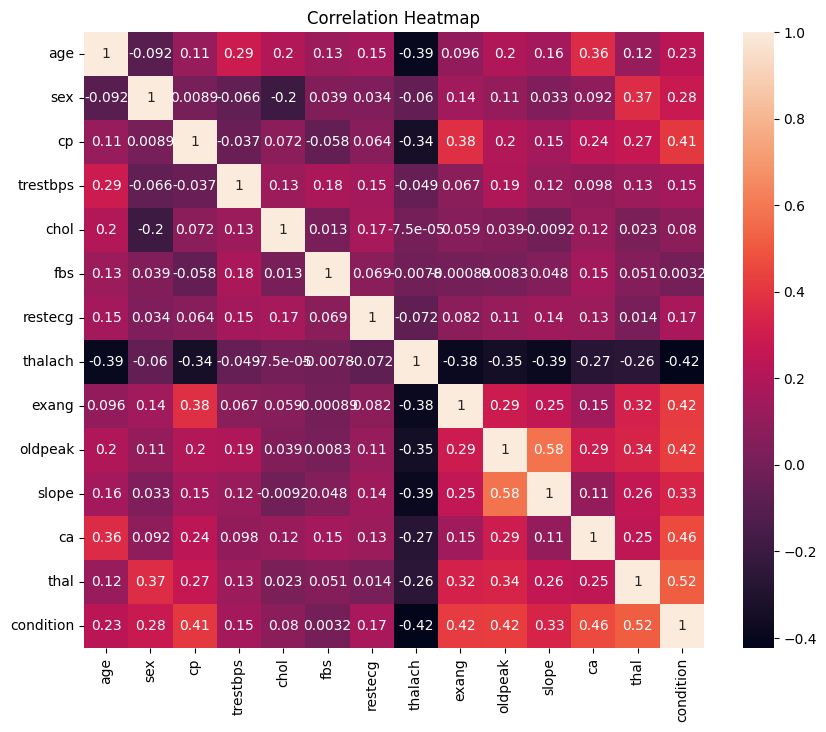

Cleaned Dataset Saved

This project helps predict heart disease using patient data.
Data analysis and visualization help identify important health
 patterns.



In [9]:
# SECTION C: ( Mini Project )

# Mini Project : Heart Disease Prediction

# First 5 Rows
print(df.head())

# Check Missing Values
print(df.isnull().sum())

# Dataset Shape
print(df.shape)

# Age Histogram
plt.hist(df['age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# Cholesterol Boxplot
sns.boxplot(x=df['chol'])
plt.title("Cholesterol Boxplot")
plt.show()

# Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Save Cleaned Dataset

df.to_csv("cleaned_heart_dataset.csv", index=False)
print("Cleaned Dataset Saved")

# Conclusion

print("""
This project helps predict heart disease using patient data.
Data analysis and visualization help identify important health
 patterns.
""")